In [3]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline 

from datetime import datetime 
import xgboost as xgb

import os

In [4]:
# data = ['transaction_id', 'is_fraud', 'created_at', 'is_subscription', 'transaction_type',
#         'currency_amount', 'currency_id', 'amount_scaled', 'merchant_customer_id',
#         'merchant_country', 'ip_address', 'platform', 'merchant_id', 'merchant_shop_id',
#         'merchant_shop_name', 'is_secured', 'ip_country', 'payment_type', 'card_id', 
#         'bank', 'cardcountry', 'bin', 'card_holder_first_name', 'card_holder_last_name']

data = ['transaction_id', 'is_fraud', 'created_at', 'is_subscription', 'transaction_type',
        'currency_amount', 'currency_id', 'amount_scaled', 'merchant_customer_id',
        'merchant_customer_email', 'merchant_country', 'merchant_language', 'ip_address',
        'platform', 'merchant_id', 'merchant_shop_id', 'merchant_shop_name', 'is_secured',
        'ip_country', 'payment_type', 'user_agent', 'card_id', 'bank', 'cardbrand',
        'cardcountry', 'cardtype', 'bin', 'card_exp_relative', 'card_holder_first_name',
        'card_holder_last_name']

In [ ]:
!python --version

In [5]:
train_path = '/kaggle/input/int20h_test_2025/train.csv' 

In [6]:
total_rows = sum(1 for _ in open(train_path)) - 1  # -1 for header
indices_to_skip = set(np.random.choice(
    range(1, total_rows + 1),  # Skip from row 1 (after header)
    size=int(total_rows * 0.60),  # Skip 65% of rows
    replace=False
))

# Read CSV skipping the selected rows
train = pd.read_csv(train_path, 
                 skiprows=lambda x: x in indices_to_skip, usecols=data)

In [5]:
train.head()

,transaction_id,is_fraud,created_at,is_subscription,transaction_type,currency_amount,currency_id,amount_scaled,merchant_customer_id,merchant_customer_email,...,device,card_id,bank,cardbrand,cardcountry,cardtype,bin,card_exp_relative,card_holder_first_name,card_holder_last_name
0,8147581512265419576,0,2024-01-28 06:31:26.253682787,True,first,1078.65,4,526,2ae2b02e168b5614f46a2b94715562012cf01f405b4da2...,53514d7fdcf50004badc5914c5faaad5311e94b9596c90...,...,NaN,1137f5c95cbd1e9c6513b475f0cc4ebf1df27afa23a6b3...,Suncorp-Metway Limited,VISA,AUS,DEBIT,6e23dbda72e8f0b5236187e648159b5cca78fb829b56f7...,43.0,NaN,NaN
1,13648480354949313259,0,2024-01-24 10:50:45.253682787,True,first,3508.65,4,1712,598fb6fd155539f799381de181b70e797fb8d95fb8b195...,8a6e8551c0910c7fa2708245b1bcecd17ea8c3fec97795...,...,NaN,1d67a084f600525977e39f6ed823468acef0b55fb0774f...,COMMONWEALTH BANK OF AUSTRALIA,MASTERCARD,AUS,DEBIT,57629399358b0beb64e63a8635251bbb748b65a537cab6...,25.0,NaN,NaN
2,9831993196115954176,0,2024-01-25 01:29:09.253682787,True,first,201.15,4,98,f71da12aae40319b06463aaea0743bb837d6ae57daad9b...,f55b3a153c12df7a7660514ea201f795dd29aca085ce13...,...,NaN,a3a725b5db4a07666b58aba4450068d5474c6f0cd79f1f...,COMMONWEALTH BANK OF AUSTRALIA,MASTERCARD,AUS,CREDIT,2970ea11ed79de67d4571d066232919d75cdcde8b6f76d...,35.0,NaN,NaN
3,18014536142395549919,0,2024-01-25 04:06:50.253682787,True,first,201.15,4,98,b250c004244f8e9baa8685b4703be3ac557398b19c2377...,f50d888713313fcf6a42286800205e52acfab62ad54a6c...,...,NaN,07d3ea4d7db7fd8c76538475859b38595b9a2cc6ee6066...,COMMONWEALTH BANK OF AUSTRALIA,MASTERCARD,AUS,DEBIT,ead17e1bf2b82a0a6a2076ed299488f21c09f77fa1372f...,32.0,NaN,NaN
4,2755652965399468914,0,2024-01-22 04:24:46.253682787,True,first,201.15,4,99,f02bfe263a64e5fc3572a643acdf2ec7bcae48c5d9b0d5...,73782a86ebef91d85f83d59e649ae09f1548eca2a35ade...,...,NaN,0cbd5eba3878bc0e789469d4d94642aba60f38fc73ccc8...,COMMONWEALTH BANK OF AUSTRALIA,MASTERCARD,AUS,DEBIT,ead17e1bf2b82a0a6a2076ed299488f21c09f77fa1372f...,32.0,NaN,NaN


In [6]:
train.isnull().sum()

transaction_id                        0
is_fraud                              0
created_at                            0
is_subscription                       0
transaction_type                      0
currency_amount                       0
currency_id                           0
amount_scaled                         0
merchant_customer_id            1320547
merchant_customer_email               3
merchant_customer_phone         8788260
merchant_customer_first_name    7978219
merchant_customer_last_name     8310152
merchant_country                      1
merchant_city                   8840146
merchant_language               2104469
ip_address                            1
platform                              0
merchant_id                           0
merchant_shop_id                      0
merchant_shop_name                    0
is_secured                            0
order_number                    8704513
ip_country                        34768
is_verified                     9069661


In [7]:
train['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.960884
1    0.039116
Name: proportion, dtype: float64

In [8]:
train.dropna(inplace=True)

In [10]:
train['is
_fraud'].value_counts(normalize=True)

Series([], Name: proportion, dtype: float64)

In [5]:
train['transaction_type'].value_counts(normalize=True)

Series([], Name: proportion, dtype: float64)

In [9]:
train.describe()

,transaction_id,is_fraud,currency_amount,currency_id,amount_scaled,merchant_id,merchant_shop_id,card_exp_relative
count,3.749700e+04,37497.000000,3.749700e+04,37497.000000,37497.000000,3.749700e+04,37497.000000,37497.000000
mean,9.222044e+18,0.027282,2.036436e+04,111.390485,1246.786010,1.316068e+19,11827.071819,45.492759
std,5.331496e+18,0.162907,5.649341e+04,44.369543,1739.012941,1.667816e+18,7190.560334,20.499691
min,2.831540e+14,0.000000,1.350000e+00,3.000000,1.000000,8.627844e+16,9.000000,-1.000000
25%,4.615709e+18,0.000000,6.210000e+02,122.000000,139.000000,1.249847e+19,89.000000,32.000000
50%,9.214620e+18,0.000000,3.913650e+03,122.000000,460.000000,1.249847e+19,16482.000000,49.000000
75%,1.382880e+19,0.000000,7.508700e+03,122.000000,1459.000000,1.249847e+19,16529.000000,58.000000
max,1.844625e+19,1.000000,1.590493e+06,163.000000,110538.000000,1.816800e+19,19296.000000,580.000000


In [18]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

def analyze_correlations_in_chunks(file_path, chunk_size=100000):
    first_chunk = True
    correlation_sum = None
    n_chunks = 0
    
    for chunk in pd.read_csv(file_path, chunksize=chunk_size, low_memory=False):
        numeric_chunk = chunk.select_dtypes(include=[np.number])
        chunk_corr = numeric_chunk.corr()
        
        if first_chunk:
            correlation_sum = chunk_corr
            first_chunk = False
        else:
            correlation_sum += chunk_corr
        
        n_chunks += 1
    
    return correlation_sum / n_chunks

def plot_correlation_matrix(correlation_matrix):
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Feature Correlation Matrix')
    plt.tight_layout()
    plt.show()

In [15]:
def analyze_fraud_patterns(file_path, target_column='fraud_label', chunk_size=100000):
    # Initialize statistics dictionaries
    feature_stats = {}
    class_distributions = {0: 0, 1: 0}
    
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        # Update class distribution
        class_counts = chunk[target_column].value_counts()
        for label in class_counts.index:
            class_distributions[label] += class_counts[label]
        
        # Calculate statistics for numeric columns
        numeric_chunk = chunk.select_dtypes(include=[np.number])
        for column in numeric_chunk.columns:
            if column not in feature_stats:
                feature_stats[column] = {
                    'mean_fraud': [],
                    'mean_normal': [],
                    'std_fraud': [],
                    'std_normal': []
                }
            
            # Calculate statistics by class
            fraud_stats = numeric_chunk[chunk[target_column] == 1][column].agg(['mean', 'std'])
            normal_stats = numeric_chunk[chunk[target_column] == 0][column].agg(['mean', 'std'])
            
            feature_stats[column]['mean_fraud'].append(fraud_stats['mean'])
            feature_stats[column]['mean_normal'].append(normal_stats['mean'])
            feature_stats[column]['std_fraud'].append(fraud_stats['std'])
            feature_stats[column]['std_normal'].append(normal_stats['std'])
    
    # Combine statistics across chunks
    for column in feature_stats:
        for stat in ['mean_fraud', 'mean_normal', 'std_fraud', 'std_normal']:
            feature_stats[column][stat] = np.mean(feature_stats[column][stat])
    
    return feature_stats, class_distributions

def calculate_feature_importance_scores(feature_stats):
    importance_scores = {}
    for feature in feature_stats:
        # Calculate separation between fraud and normal distributions
        mean_difference = abs(feature_stats[feature]['mean_fraud'] - 
                            feature_stats[feature]['mean_normal'])
        pooled_std = np.sqrt((feature_stats[feature]['std_fraud']**2 + 
                            feature_stats[feature]['std_normal']**2) / 2)
        
        # Calculate effect size (Cohen's d)
        importance_scores[feature] = mean_difference / pooled_std if pooled_std != 0 else 0
    
    return importance_scores

In [16]:
def analyze_outliers_by_class(file_path, target_column='fraud_label', chunk_size=100000):
    outlier_stats = {}
    
    for chunk in pd.read_csv(file_path, chunksize=chunk_size):
        numeric_chunk = chunk.select_dtypes(include=[np.number])
        
        for column in numeric_chunk.columns:
            if column != target_column:
                if column not in outlier_stats:
                    outlier_stats[column] = {'fraud_outliers': 0, 'normal_outliers': 0, 'total_rows': 0}
                
                # Calculate IQR for outlier detection
                Q1 = numeric_chunk[column].quantile(0.25)
                Q3 = numeric_chunk[column].quantile(0.75)
                IQR = Q3 - Q1
                
                # Count outliers by class
                outliers = (numeric_chunk[column] < (Q1 - 1.5 * IQR)) | (numeric_chunk[column] > (Q3 + 1.5 * IQR))
                outlier_stats[column]['fraud_outliers'] += sum(outliers & (chunk[target_column] == 1))
                outlier_stats[column]['normal_outliers'] += sum(outliers & (chunk[target_column] == 0))
                outlier_stats[column]['total_rows'] += len(chunk)
    
    return outlier_stats

/usr/local/lib/python3.10/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


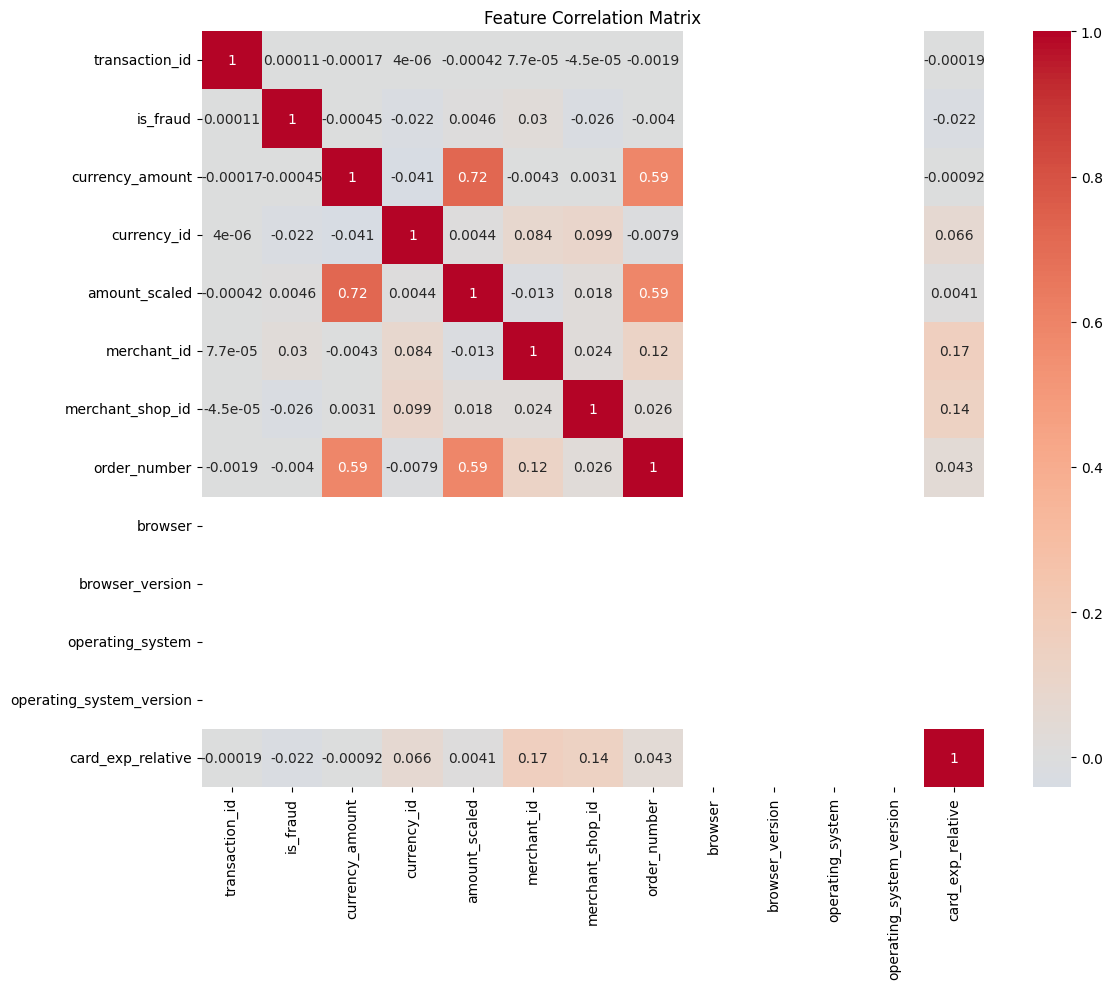

KeyError: 'fraud_label'

In [19]:
# Run the analyses


# 1. Correlation Analysis
correlation_matrix = analyze_correlations_in_chunks(train_path)
plot_correlation_matrix(correlation_matrix)

# 2. Fraud Patterns Analysis
feature_stats, class_distribution = analyze_fraud_patterns(train_path)
importance_scores = calculate_feature_importance_scores(feature_stats)

# 3. Outlier Analysis
outlier_stats = analyze_outliers_by_class(train_path)

# Print key findings
print("\nClass Distribution:")
print(class_distribution)

print("\nTop 10 Most Important Features:")
sorted_features = sorted(importance_scores.items(), key=lambda x: x[1], reverse=True)[:10]
for feature, score in sorted_features:
    print(f"{feature}: {score:.3f}")

print("\nOutlier Analysis:")
for column, stats in outlier_stats.items():
    fraud_rate = stats['fraud_outliers'] / stats['total_rows'] * 100
    normal_rate = stats['normal_outliers'] / stats['total_rows'] * 100
    print(f"{column}: Fraud outlier rate: {fraud_rate:.2f}%, Normal outlier rate: {normal_rate:.2f}%")

In [ ]:
data = ['transaction_id', 'is_fraud', 'created_at', 'is_subscription', 'transaction_type',
        'currency_amount', 'currency_id', 'amount_scaled', 'merchant_customer_id',
        'merchant_customer_email', 'merchant_country', 'merchant_language', 'ip_address',
        'platform', 'merchant_id', 'merchant_shop_id', 'merchant_shop_name', 'is_secured',
        'ip_country', 'payment_type', 'user_agent', 'card_id', 'bank', 'cardbrand',
        'cardcountry', 'cardtype', 'bin', 'card_exp_relative', 'card_holder_first_name',
        'card_holder_last_name']

train

In [12]:
plt.figure(figsize=(20, 10))
sns.heatmap(train.corr(), annot=True)
plt.show()

ValueError: could not convert string to float: '2024-01-24 06:34:28.253682787'

<Figure size 2000x1000 with 0 Axes>